In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from build_dataset import build_dataset
from itertools import product

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
words_corpus = open("names.txt", "r").read().splitlines()
words_corpus[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


#### Build the vocabulary of characters and mapping to/from integers

In [5]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


In [6]:
stoi = {letter:index+1 for index, letter in enumerate(chars_corpus)} #This for making the letters and the index
stoi['.'] = 0 #Its the first index its going to be .
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [7]:
itos = {index:letter for letter,index in stoi.items()}
print(len(itos))

27


#### Build the Dataset

In [76]:
import random
block_size_context = 8  #the context length: how many characters 
                        # the model sees to predict the next one
                        # e.g. "_ _ _ -> ?"


random.seed(42) #This is for reproducibility
random.shuffle(words_corpus)
n1 = int(0.80 * len(words_corpus)) #This is for the training set
n2 = int(0.90 * len(words_corpus)) #This is for the validation set and the test set

X_training, Y_training = build_dataset(words_corpus=words_corpus[:n1],block_size=block_size_context, stoi=stoi) #until 80%
X_validation, Y_validation = build_dataset(words_corpus=words_corpus[n1:n2], block_size=block_size_context, stoi=stoi) #10 for validation
X_test, Y_test = build_dataset(words_corpus=words_corpus[n2:], block_size=block_size_context, stoi=stoi)#10 for test

torch.Size([182661, 8]) torch.Size([182661])
torch.Size([22763, 8]) torch.Size([22763])
torch.Size([22722, 8]) torch.Size([22722])


In [77]:
import torch.nn.init as init
from mlp_torch import Sequential, Embedding, FlattenConsecutive, Linear, BatchNorm1D, Tanh

#MLP revisited hyper parameters
# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 256 # the number of neurons in the hidden layer of the MLP
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)


In [78]:
model = Sequential([
    Embedding(num_embeddings=lenght_characters_dataset, embedding_dim=n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, lenght_characters_dataset, generator=generator)
])

#Paramter init
# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


283555


In [79]:
#Same optimization as the last time

max_steps = 200000 #This are the epochs
lossi = []
for i in range(max_steps):
    
    #The minibatch construct
    ix = torch.randint(0, X_training.shape[0], (batch_size, ))
    Xb, Yb = X_training[ix], Y_training[ix] #Batch X, Y
    
    #Forward pass
    logits = model(Xb) #the prediction of the model with the training sample
    loss = F.cross_entropy(logits, Yb) #The loss fuction of the model and compared between the logits and the label
    
    #Backward pass 
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    #Update: Simple SGD
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
     # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    

      0/ 200000: 3.2921
  10000/ 200000: 1.9381
  20000/ 200000: 2.3544
  30000/ 200000: 1.9809
  40000/ 200000: 2.1633
  50000/ 200000: 1.6941
  60000/ 200000: 1.9074
  70000/ 200000: 2.2295
  80000/ 200000: 1.8656
  90000/ 200000: 2.1309
 100000/ 200000: 2.2473
 110000/ 200000: 1.8491
 120000/ 200000: 1.7476
 130000/ 200000: 1.6694
 140000/ 200000: 1.9126
 150000/ 200000: 1.5193
 160000/ 200000: 2.1441
 170000/ 200000: 1.6183
 180000/ 200000: 1.5889
 190000/ 200000: 2.0633


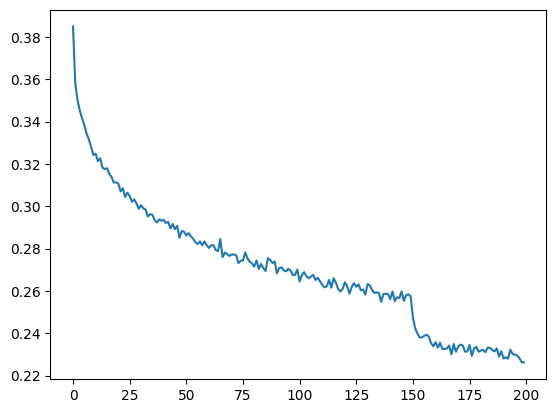

In [81]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [82]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [83]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (X_training, Y_training),
    'val': (X_validation, Y_validation),
    'test': (X_test, Y_test),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.674190878868103
val 1.9823917150497437


### Booklog

With 8 words of context and 5 layers 2.042 val loss. Parameters 76579


With 8 words of the context and more Nuerons(256) layers the val loss its 1.98, its better


With 16 words and more hidden layers (1 more) and (256 nuerons) the val loss its 2.0923, its telling that there are overfitting

In [84]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size_context # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated

shriella.
mokiyah.
cameron.
koralyn.
kalyssa.
sanat.
luntana.
jahad.
xanna.
mahata.
jeanna.
kallion.
leone.
alexce.
kaston.
graciere.
raylynn.
galaxie.
kobii.
israella.
